Running simulations with N = 10,000 nodes...
  θ = 0.0, T_max = 40...
    M(0)=1.0163e-06, M(end)=0.9996
  θ = 0.1, T_max = 44...
    M(0)=1.0163e-06, M(end)=1.0021
  θ = 0.3, T_max = 53...
    M(0)=1.0163e-06, M(end)=1.0028
  θ = 0.5, T_max = 62...
    M(0)=1.0163e-06, M(end)=0.9981
  θ = 0.7, T_max = 71...
    M(0)=1.0163e-06, M(end)=0.9996
  θ = 1.0, T_max = 84...
    M(0)=1.0163e-06, M(end)=1.0003

Plots saved.


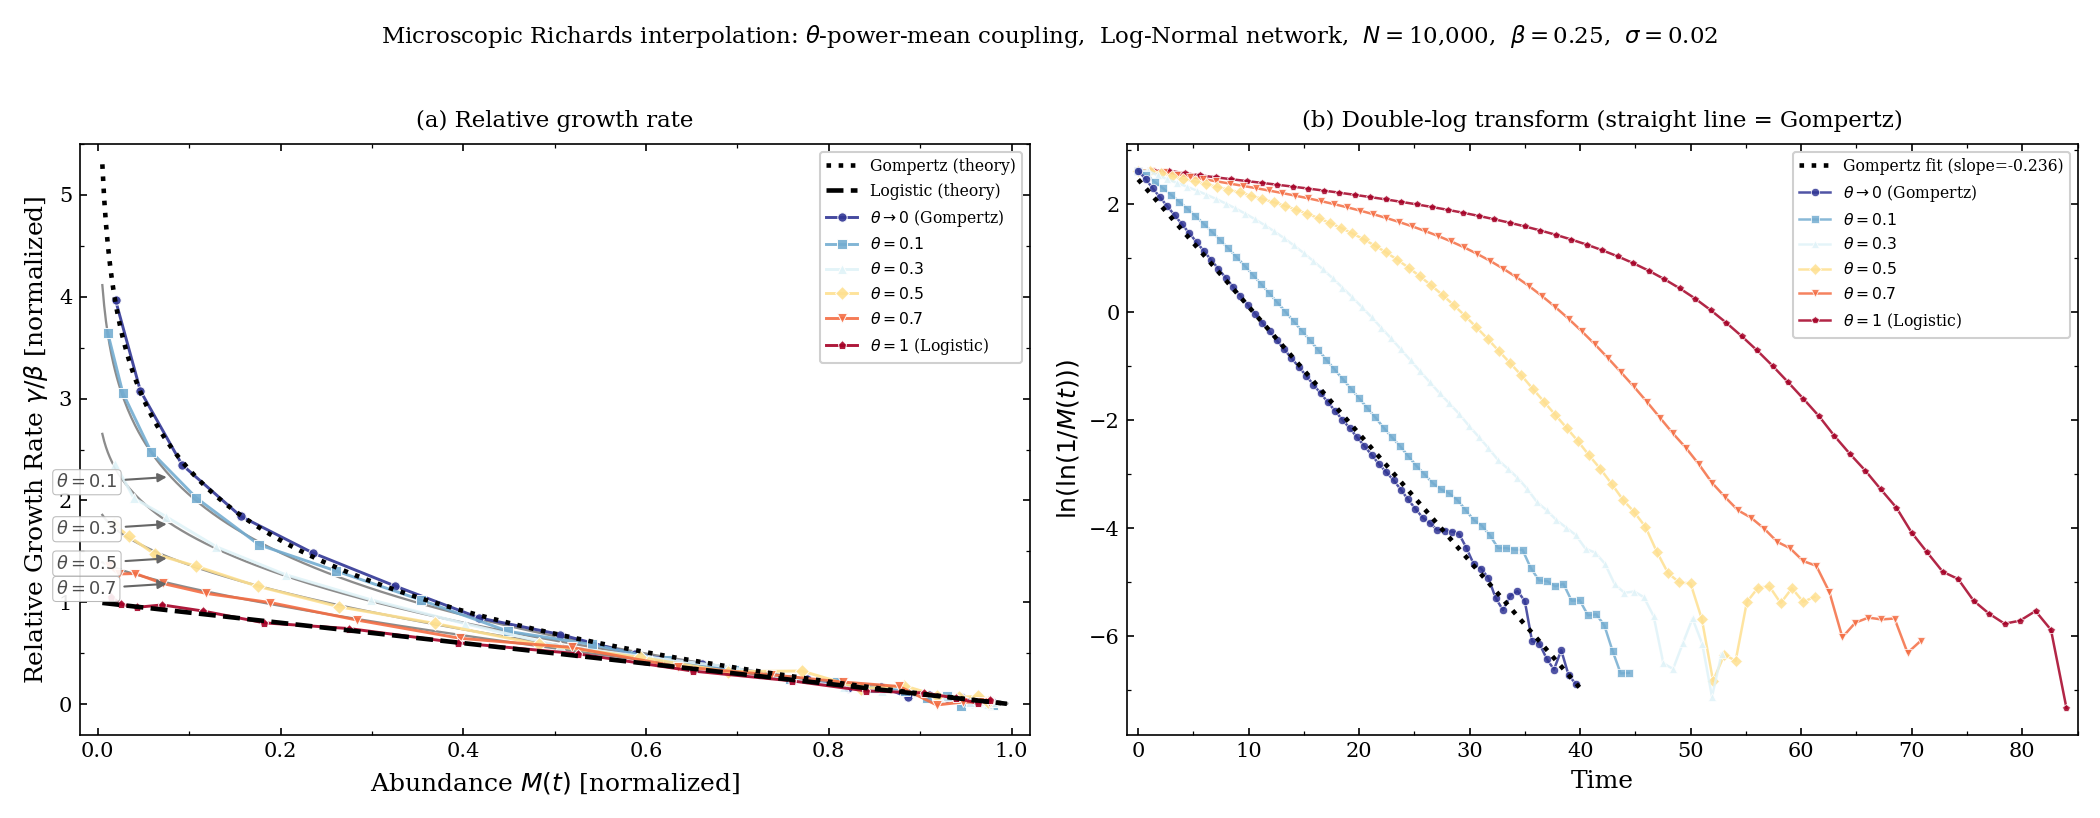

In [1]:
"""
Microscopic Gompertz-to-Logistic via Power-Mean Coupling
=========================================================
Uses a power-mean interpolation to smoothly transition between
geometric-mean coupling (Gompertz, θ→0) and arithmetic-mean
coupling (Logistic, θ=1).

The power mean of order θ is:
    M_θ(x) = (1/N Σ x_i^θ)^{1/θ}

which gives the geometric mean at θ→0 and arithmetic mean at θ=1.

Microscopic model:
    dz_i/dt = -(β/θ)(1 - e^{θ z_i}) + β(z̄_θ - z_i)

where z̄_θ = (1/θ) ln(Σ w_j e^{θ z_j}) is the power-mean in log-domain.

At θ→0 both the drift and coupling reduce to Gompertz.
At θ=1 both reduce to logistic-like dynamics.

FIX: For θ→1 with very negative initial z, the arithmetic-mean coupling
creates outlier-driven kicks that destabilize the Euler scheme. We use
an adaptive sub-stepping approach: when the maximum |dz| in a proposed
step exceeds a threshold, we subdivide that step into smaller increments.
This preserves the exact same dynamics while keeping the integration stable.
"""
"""
Microscopic Gompertz-to-Logistic via Power-Mean Coupling
=========================================================
With double-log panel and visible instability at high theta.
Adaptive sub-stepping is DISABLED to show the instability honestly.
Noise is increased to make the effect visible.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import warnings
warnings.filterwarnings("ignore")

# ─── Parameters ───────────────────────────────────────────────────────────────

N = 10_000
BETA = 0.25
SIGMA = 0.02          # higher noise to show instability at high theta
DT = 0.02
T_MAX = 40.0
SEED = 42

# ─── Network ──────────────────────────────────────────────────────────────────

def degree_log_normal(N, rng):
    z = rng.standard_normal(N)
    return np.maximum(2, np.round(np.exp(1.5 + 0.8 * z)).astype(int))

def build_weights(degrees):
    k = degrees.astype(np.float64)
    return k / k.sum()

# ─── Compute drift + coupling ────────────────────────────────────────────────

def compute_tendency(z, theta, weights, eps=1e-8):
    if theta < eps:
        drift = -BETA * z
        z_bar = np.sum(weights * z)
        coupling = BETA * (z_bar - z)
    else:
        eth = np.exp(np.clip(theta * z, -100, 2))
        drift = (BETA / theta) * (1.0 - eth)
        eth_bar = np.sum(weights * eth)
        pm_log = np.log(np.clip(eth_bar, 1e-30, None)) / theta
        coupling = BETA * (pm_log - z)
    return drift + coupling

# ─── Simulation — NO adaptive sub-stepping to expose instability ─────────────

def simulate_theta(theta, rng_seed, t_max=T_MAX):
    r = np.random.default_rng(rng_seed)
    degrees = degree_log_normal(N, r)
    weights = build_weights(degrees)

    z = r.normal(loc=-13.8, scale=0.03, size=N)
    steps = int(t_max / DT)
    M_traj = np.zeros(steps + 1)
    M_traj[0] = np.exp(np.mean(z))
    noise_scale = np.sqrt(SIGMA * DT)

    for t_idx in range(steps):
        tendency = compute_tendency(z, theta, weights)
        dz = tendency * DT + noise_scale * r.standard_normal(N)
        z += dz
        M_traj[t_idx + 1] = np.exp(np.mean(z))

    return M_traj

# ─── Theoretical curves ──────────────────────────────────────────────────────

def gompertz_gamma(M):
    return -np.log(np.clip(M, 1e-15, None))

def logistic_gamma(M):
    return 1 - M

def richards_gamma(M, theta):
    return (1 - np.clip(M, 1e-15, None)**theta) / theta

# ─── Run simulations ─────────────────────────────────────────────────────────

thetas = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
labels = {
    0.0:  r"$\theta \to 0$ (Gompertz)",
    0.1:  r"$\theta = 0.1$",
    0.3:  r"$\theta = 0.3$",
    0.5:  r"$\theta = 0.5$",
    0.7:  r"$\theta = 0.7$",
    1.0:  r"$\theta = 1$ (Logistic)",
}

print(f"Running simulations with N = {N:,} nodes...")
results = {}
t_maxes = {}
for th in thetas:
    t_max = T_MAX * max(1.0, 1 + 1.1 * th)
    t_maxes[th] = t_max
    print(f"  θ = {th}, T_max = {t_max:.0f}...")
    M = simulate_theta(th, SEED, t_max=t_max)
    results[th] = M
    print(f"    M(0)={M[0]:.4e}, M(end)={M[-1]:.4f}")

# ─── Plotting ─────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 12,
    "legend.fontsize": 8,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "legend.edgecolor": "0.8",
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.15,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

M_th = np.linspace(0.005, 0.995, 500)

# ── Left panel: Relative growth rate vs abundance ──

# Theoretical Richards family
for th_ref in [0.1, 0.3, 0.5, 0.7]:
    ax1.plot(M_th, richards_gamma(M_th, th_ref),
             color="0.55", lw=1.1, ls="-", zorder=5)

ax1.plot(M_th, gompertz_gamma(M_th), color="black", lw=2.2, ls=":",
         label="Gompertz (theory)", zorder=10)
ax1.plot(M_th, logistic_gamma(M_th), color="black", lw=2.2, ls="--",
         label="Logistic (theory)", zorder=10)

# Annotations
annot_cfg = [
    (0.1, 0.08, (-55, -5)),
    (0.3, 0.08, (-55, -5)),
    (0.5, 0.08, (-55, -5)),
    (0.7, 0.08, (-55, -5)),
]
for th_ref, x_arrow, xytext in annot_cfg:
    y_arrow = richards_gamma(x_arrow, th_ref)
    ax1.annotate(rf"$\theta={th_ref}$", xy=(x_arrow, y_arrow),
                 xytext=xytext, textcoords="offset points",
                 fontsize=8.5, fontweight="bold", color="0.3",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", lw=0.5, alpha=0.9),
                 arrowprops=dict(arrowstyle="-|>", color="0.4", lw=1.0,
                                 connectionstyle="arc3,rad=0.0"),
                 zorder=12)

# Simulated curves
cmap = plt.cm.RdYlBu_r
colors = [cmap(i / (len(thetas) - 1)) for i in range(len(thetas))]
markers_list = ["o", "s", "^", "D", "v", "p"]

for idx, th in enumerate(thetas):
    M = results[th]
    M_norm = (M - M.min()) / (M.max() - M.min())
    M_norm = np.clip(M_norm, 1e-6, 1 - 1e-6)

    dM = np.gradient(M_norm, DT)
    gamma = dM / M_norm
    gamma_norm = gamma / BETA

    step = max(1, len(M_norm) // 40)
    M_sub = M_norm[::step]
    g_sub = gamma_norm[::step]

    mask = (M_sub > 0.01) & (M_sub < 0.98) & (g_sub > -0.5) & (g_sub < 8)
    ax1.plot(M_sub[mask], g_sub[mask],
             color=colors[idx], marker=markers_list[idx], markersize=4.5,
             lw=1.4, alpha=0.9, markeredgewidth=0.5, markeredgecolor="white",
             label=labels[th], zorder=7)

ax1.set_xlabel("Abundance $M(t)$ [normalized]")
ax1.set_ylabel(r"Relative Growth Rate $\gamma / \beta$ [normalized]")
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.3, 5.5)
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
ax1.tick_params(which="both", direction="in", top=True, right=True)
ax1.legend(loc="upper right", ncol=1, fontsize=7.5)
ax1.set_title("(a) Relative growth rate", fontsize=11, pad=8)

# ── Right panel: Double-log transform vs time ──

# Theoretical Gompertz: ln(ln(1/M)) = -β t + const, a straight line
t_theory = np.linspace(0, T_MAX, 300)
# Use the Gompertz simulation to get a representative Y0/Y_inf
M_gomp = results[0.0]
M_gomp_norm = (M_gomp - M_gomp.min()) / (M_gomp.max() - M_gomp.min())
M_gomp_norm = np.clip(M_gomp_norm, 1e-6, 1 - 1e-6)
# Fit the constant from the first valid point
with np.errstate(invalid="ignore", divide="ignore"):
    dlog_gomp = np.log(-np.log(M_gomp_norm))
valid_g = np.isfinite(dlog_gomp)
t_gomp = np.linspace(0, T_MAX, len(M_gomp))
# Linear fit to get slope and intercept
from numpy.polynomial.polynomial import polyfit
t_valid_g = t_gomp[valid_g]
dlog_valid_g = dlog_gomp[valid_g]
# Use middle portion for clean fit
mid = (t_valid_g > 2) & (t_valid_g < T_MAX - 2)
if mid.sum() > 10:
    c0, c1 = polyfit(t_valid_g[mid], dlog_valid_g[mid], 1)
    ax2.plot(t_theory, c0 + c1 * t_theory, color="black", lw=2.2, ls=":",
             label=f"Gompertz fit (slope={c1:.3f})", zorder=10)

for idx, th in enumerate(thetas):
    M = results[th]
    t_max = t_maxes[th]
    t_arr = np.linspace(0, t_max, len(M))

    M_norm = (M - M.min()) / (M.max() - M.min())
    M_norm = np.clip(M_norm, 1e-6, 1 - 1e-6)

    with np.errstate(invalid="ignore", divide="ignore"):
        dlog = np.log(-np.log(M_norm))

    valid = np.isfinite(dlog)
    t_valid = t_arr[valid]
    dlog_valid = dlog[valid]

    step = max(1, len(t_valid) // 60)
    ax2.plot(t_valid[::step], dlog_valid[::step],
             color=colors[idx], marker=markers_list[idx], markersize=4,
             lw=1.2, alpha=0.85, markeredgewidth=0.4, markeredgecolor="white",
             label=labels[th], zorder=7 - idx)

ax2.set_xlabel("Time")
ax2.set_ylabel(r"$\ln\!\left(\ln(1/M(t))\right)$")
ax2.set_xlim(-1, max(t_maxes.values()) + 1)
ax2.xaxis.set_minor_locator(AutoMinorLocator(2))
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
ax2.tick_params(which="both", direction="in", top=True, right=True)
ax2.legend(loc="upper right", ncol=1, fontsize=7.5)
ax2.set_title("(b) Double-log transform (straight line = Gompertz)", fontsize=11, pad=8)

fig.suptitle(
    r"Microscopic Richards interpolation: $\theta$-power-mean coupling"
    f",  Log-Normal network,  $N = ${N:,},  "
    r"$\beta=$" + f"{BETA},  " + r"$\sigma=$" + f"{SIGMA}",
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig("../figures/gompertz_richards_interpolation.png")
plt.savefig("../figures/gompertz_richards_interpolation.pdf")
print("\nPlots saved.")